In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
     

X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
     

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.123978,-2.170300,0.656775,0.396530,-0.283275,1
1,1.026671,-0.276197,-0.365060,0.041961,-0.200996,0
2,1.941387,0.775048,0.207056,1.821395,-0.634762,1
3,1.095195,-0.914703,2.623064,2.307198,-2.481233,1
4,1.192445,-0.927677,-0.068437,0.476336,-0.269932,1


In [2]:


# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [3]:

# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [4]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [30]:
df1 = sample_rows(df,0.2)

In [31]:
df2 = sample_rows(df,0.2)

In [32]:
df3 = sample_rows(df,0.2)

In [33]:
df2.shape

(20, 6)

In [34]:
df3.shape

(20, 6)

In [35]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [36]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [37]:


from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[1] <= 0.646\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.5, 'x[0] <= -0.608\ngini = 0.408\nsamples = 14\nvalue = [4, 10]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

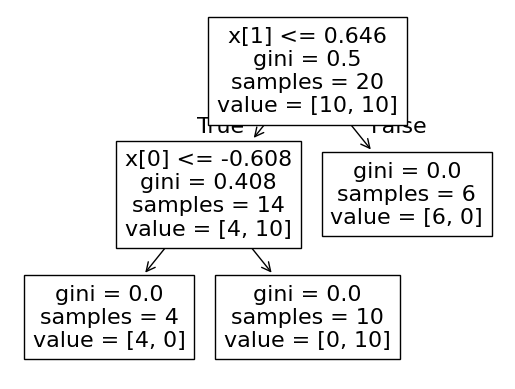

In [38]:
plot_tree(clf1)

[Text(0.5, 0.8333333333333334, 'x[1] <= -0.058\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.25, 0.5, 'x[2] <= -0.229\ngini = 0.198\nsamples = 9\nvalue = [1, 8]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]'),
 Text(0.75, 0.5, 'x[4] <= 0.483\ngini = 0.165\nsamples = 11\nvalue = [10, 1]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]')]

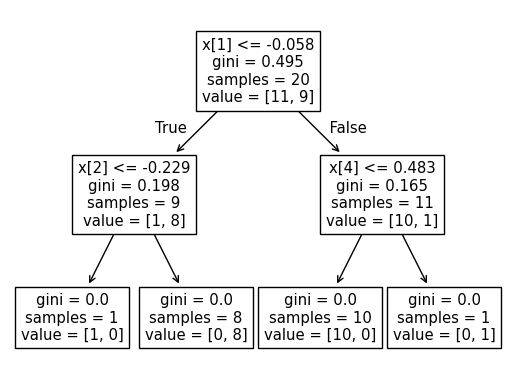

In [39]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[3] <= 1.273\ngini = 0.455\nsamples = 20\nvalue = [13, 7]'),
 Text(0.25, 0.7, 'x[1] <= -2.015\ngini = 0.245\nsamples = 14\nvalue = [12, 2]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'x[4] <= 0.648\ngini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.25, 0.3, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.5, 0.3, 'x[2] <= 1.687\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.375, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.625, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.75, 0.7, 'x[0] <= -0.131\ngini = 0.278\nsamples = 6\nvalue = [1, 5]'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.875, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]')]

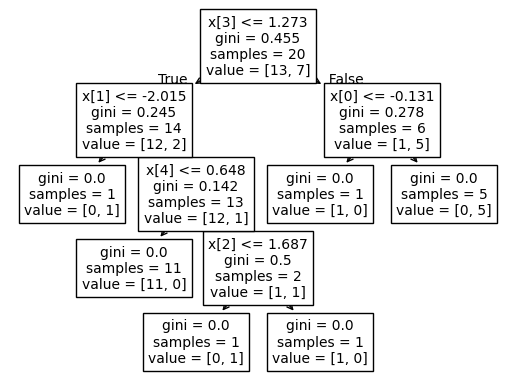

In [40]:
plot_tree(clf3)